In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Load processed dataset
df = pd.read_csv(
    "../data/processed/passthrough_dataset.csv",
    parse_dates=["date"]
).set_index("date")

# Ensure monthly frequency
df = df.asfreq("ME")


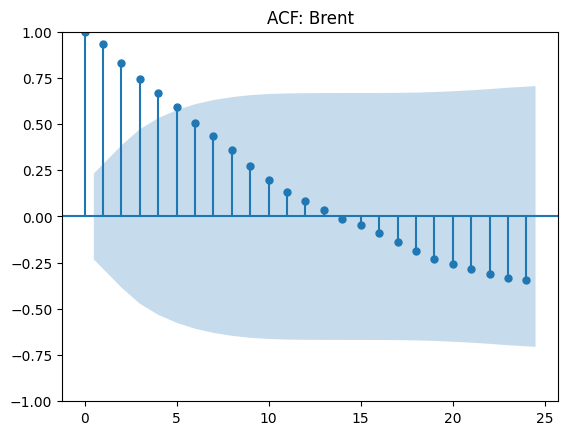

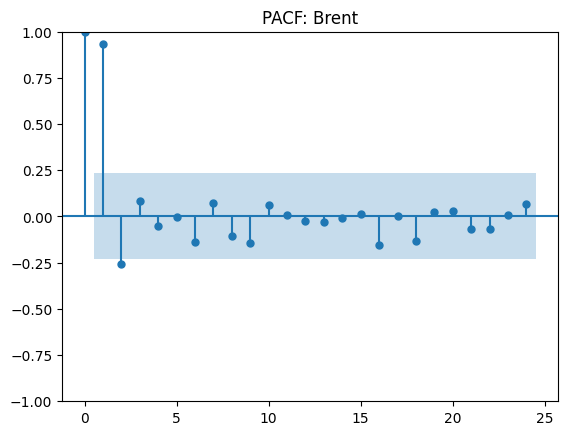

In [2]:
plot_acf(df["brent"], lags=24)
plt.title("ACF: Brent")
plt.show()

plot_pacf(df["brent"], lags=24)
plt.title("PACF: Brent")
plt.show()


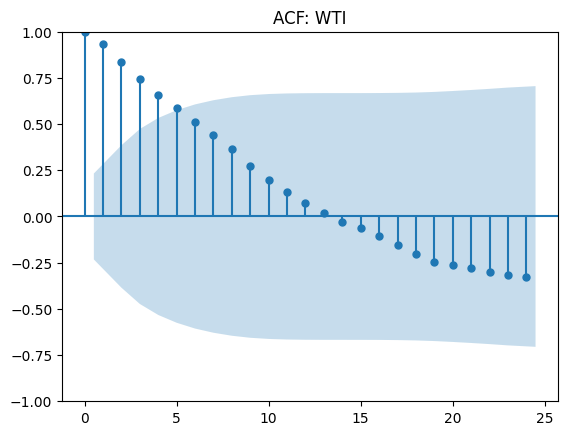

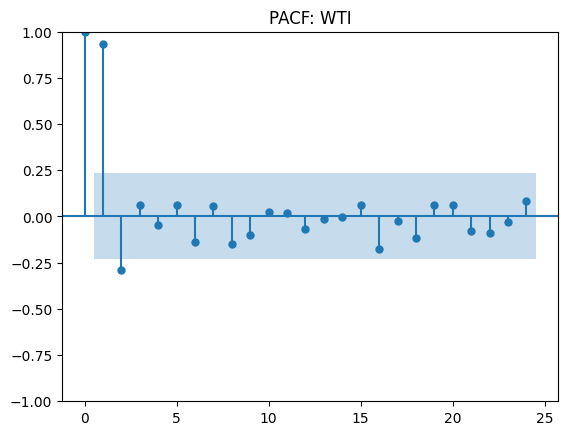

In [3]:
plot_acf(df["wti"], lags=24)
plt.title("ACF: WTI")
plt.show()

plot_pacf(df["wti"], lags=24)
plt.title("PACF: WTI")
plt.show()


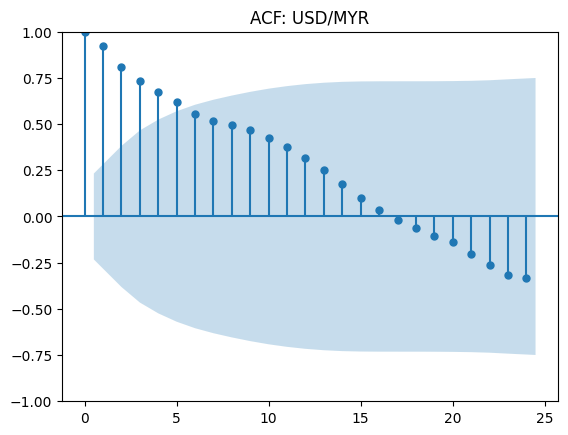

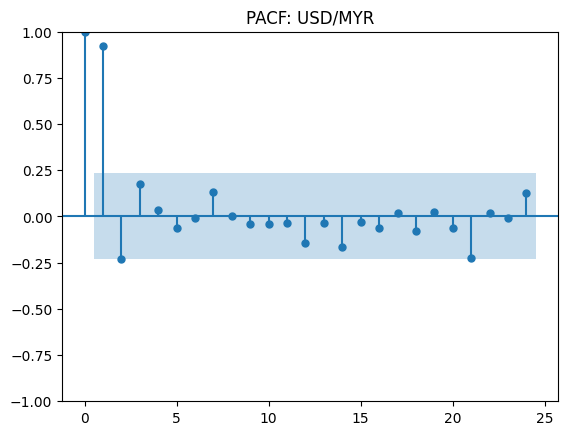

In [4]:
plot_acf(df["usdmyr"], lags=24)
plt.title("ACF: USD/MYR")
plt.show()

plot_pacf(df["usdmyr"], lags=24)
plt.title("PACF: USD/MYR")
plt.show()


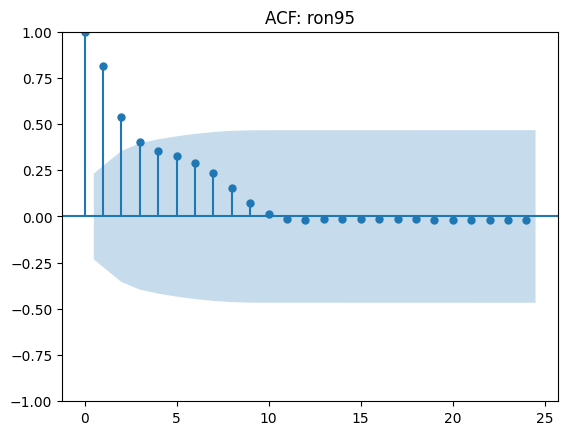

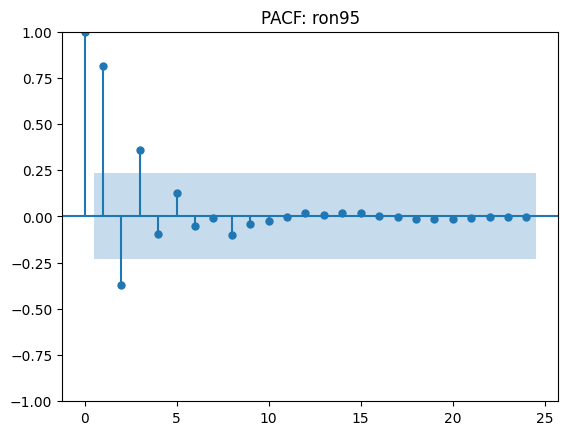

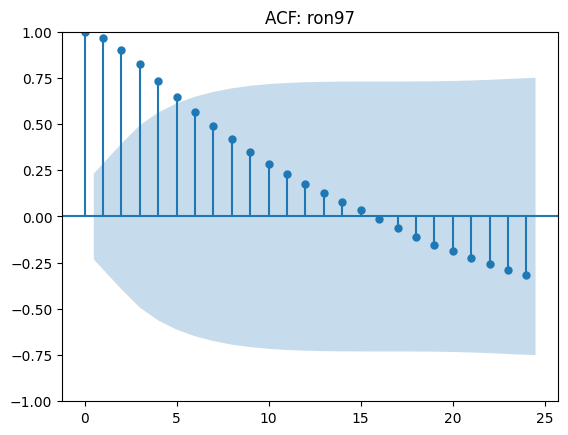

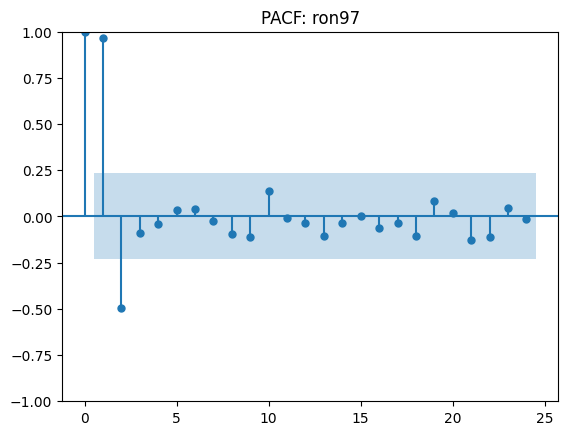

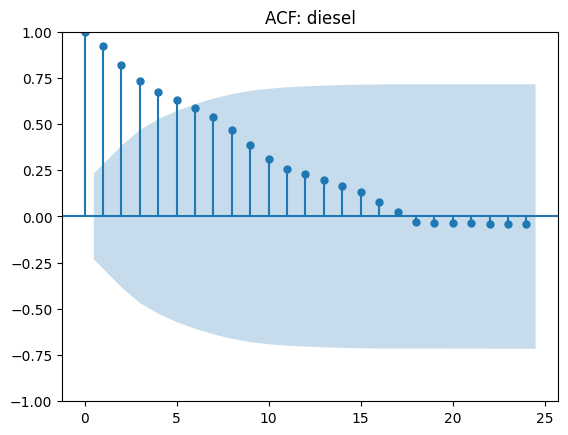

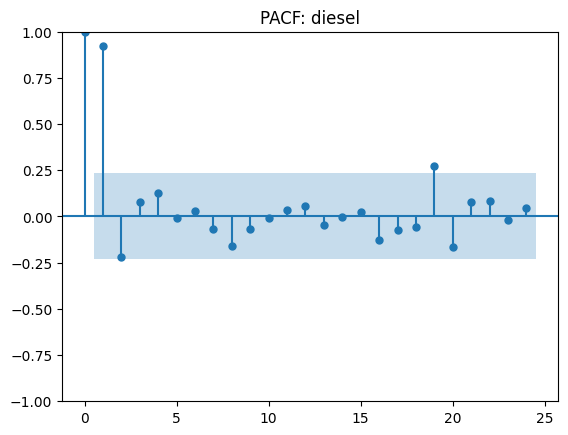

In [5]:
for col in ["ron95", "ron97", "diesel"]:
    plot_acf(df[col], lags=24)
    plt.title(f"ACF: {col}")
    plt.show()

    plot_pacf(df[col], lags=24)
    plt.title(f"PACF: {col}")
    plt.show()


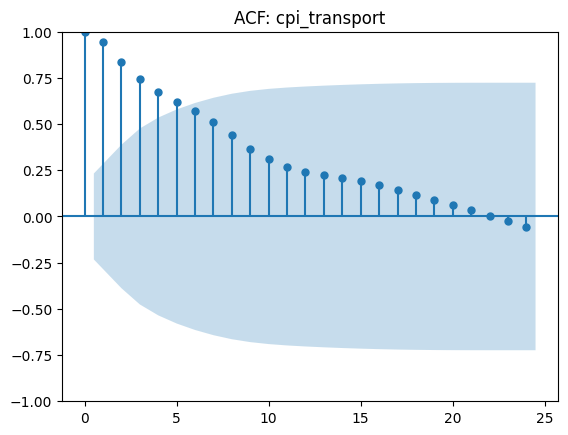

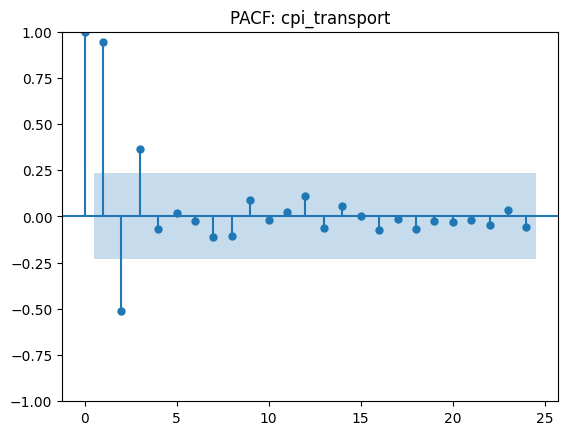

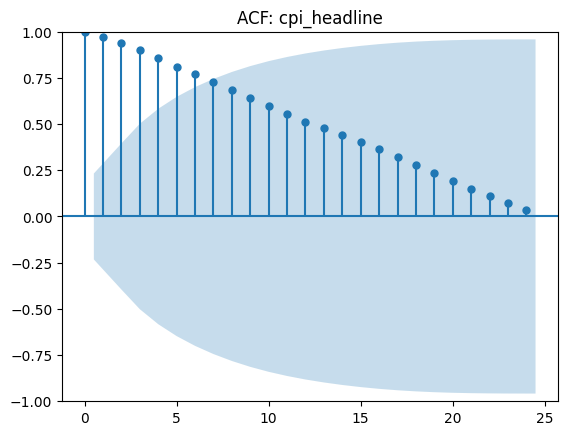

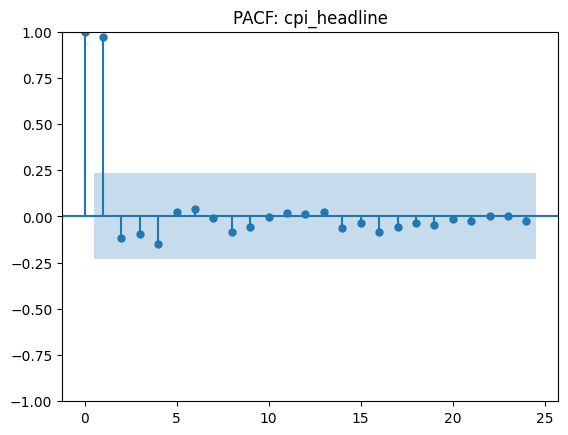

In [6]:
for col in ["cpi_transport", "cpi_headline"]:
    plot_acf(df[col], lags=24)
    plt.title(f"ACF: {col}")
    plt.show()

    plot_pacf(df[col], lags=24)
    plt.title(f"PACF: {col}")
    plt.show()


=== TABLE 4.1: DESCRIPTIVE STATISTICS ===
         mean    std    min     max  CV (%)  Skewness  Kurtosis
brent   74.38  19.95  18.38  122.71   26.82     -0.34      0.79
wti     70.45  18.80  16.55  114.84   26.69     -0.40      0.77
ron97    3.10   0.69   1.56    4.79   22.34     -0.21      0.13
ron95    2.00   0.20   1.26    2.63   10.12     -0.98      5.30
diesel   2.31   0.44   1.47    3.35   19.28      0.76     -0.27
usdmyr   4.37   0.21   4.04    4.77    4.85      0.43     -1.02

=== TABLE 4.2: PEARSON CORRELATION MATRIX ===
               brent    wti  usdmyr  ron97  ron95  diesel  cpi_transport
brent          1.000  0.998   0.423  0.919  0.601   0.246          0.744
wti            0.998  1.000   0.413  0.908  0.601   0.255          0.741
usdmyr         0.423  0.413   1.000  0.561  0.133   0.124          0.460
ron97          0.919  0.908   0.561  1.000  0.625   0.381          0.820
ron95          0.601  0.601   0.133  0.625  1.000   0.597          0.844
diesel         0.246  0.2

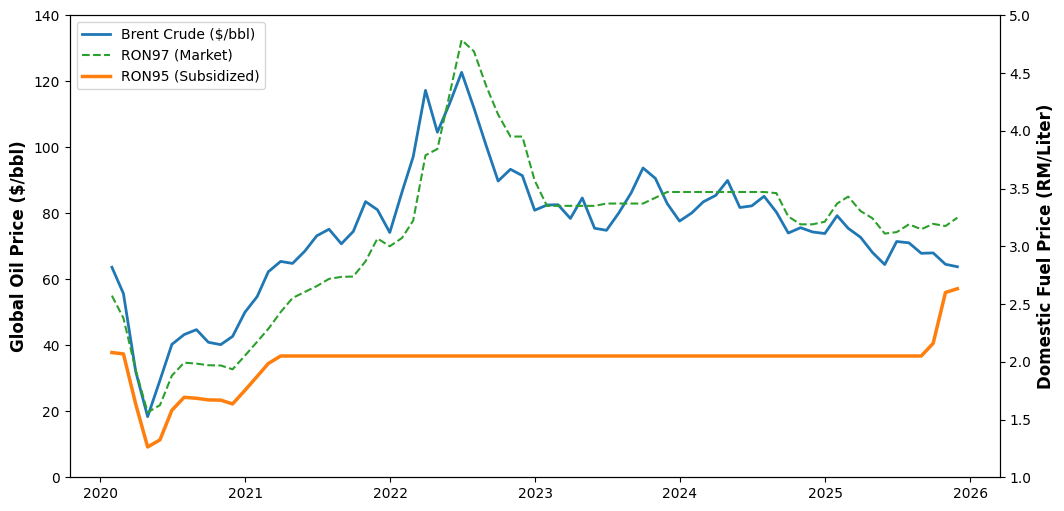

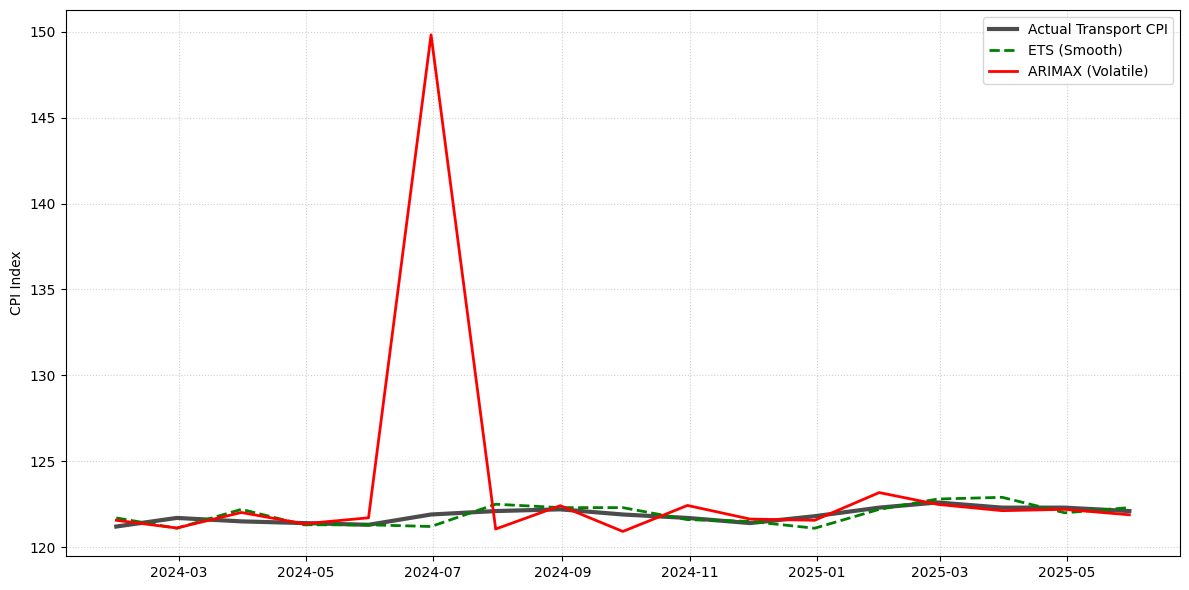


Assets Generated: 'fuel_price_trends.png' and 'forecast_comparison_transport_cpi.png'


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ==========================================
# 1. SETUP & DATA LOADING
# ==========================================
# Load the datasets uploaded by the user
df_pass = pd.read_csv('../data/processed/passthrough_dataset.csv', parse_dates=['date'], index_col='date')
df_metrics = pd.read_csv('../data/outputs/forecast_metrics_all.csv')
df_scenarios = pd.read_csv('../data/outputs_dashboard/dashboard_scenarios.csv')
df_forecasts = pd.read_csv('../data/outputs/rolling_forecasts_all.csv', parse_dates=['origin'])

# ==========================================
# 2. GENERATE TABLE 4.1 (Descriptive Stats)
# ==========================================
desc_cols = ['brent', 'wti', 'ron97', 'ron95', 'diesel', 'usdmyr']
stats = df_pass[desc_cols].describe().T[['mean', 'std', 'min', 'max']]
stats['CV (%)'] = (stats['std'] / stats['mean']) * 100
stats['Skewness'] = df_pass[desc_cols].skew()
stats['Kurtosis'] = df_pass[desc_cols].kurtosis()
print("=== TABLE 4.1: DESCRIPTIVE STATISTICS ===")
print(stats.round(2))

# ==========================================
# 3. GENERATE TABLE 4.2 (Correlation Matrix)
# ==========================================
corr_matrix = df_pass[['brent', 'wti', 'usdmyr', 'ron97', 'ron95', 'diesel', 'cpi_transport']].corr()
print("\n=== TABLE 4.2: PEARSON CORRELATION MATRIX ===")
print(corr_matrix.round(3))

# ==========================================
# 4. GENERATE FIGURE 4.1 (Trends)
# ==========================================
fig, ax1 = plt.subplots(figsize=(12, 6))

# Left Axis: Global Oil
color_brent = '#1f77b4' # Blue
ax1.plot(df_pass.index, df_pass['brent'], label='Brent Crude ($/bbl)', color=color_brent, linewidth=2)
ax1.set_ylabel('Global Oil Price ($/bbl)', color='black', fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='black')
ax1.set_ylim(0, 140)

# Right Axis: Domestic Fuel
ax2 = ax1.twinx()
color_ron95 = '#ff7f0e' # Orange
color_ron97 = '#2ca02c' # Green
ax2.plot(df_pass.index, df_pass['ron97'], label='RON97 (Market)', color=color_ron97, linestyle='--')
ax2.plot(df_pass.index, df_pass['ron95'], label='RON95 (Subsidized)', color=color_ron95, linewidth=2.5)
ax2.set_ylabel('Domestic Fuel Price (RM/Liter)', color='black', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='black')
ax2.set_ylim(1.0, 5.0)

# Annotation: The Decoupling
peak_date = pd.Timestamp('2022-06-01')


# Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')


plt.savefig('../draft/fuel_price_trends.png', dpi=300)
plt.show()

# ==========================================
# 5. GENERATE FIGURE 4.2 (Forecast Failure)
# ==========================================
# Filter for Transport CPI, Horizon=1
subset = df_forecasts[(df_forecasts['target'] == 'cpi_transport') & (df_forecasts['horizon'] == 1)].sort_values('origin')

plt.figure(figsize=(12, 6))
# Plot Actuals
plt.plot(subset['origin'], subset['y_true'], label='Actual Transport CPI', color='black', linewidth=3, alpha=0.7)
# Plot ETS (Univariate - Good)
ets = subset[subset['model'].str.contains('ETS')]
plt.plot(ets['origin'], ets['y_pred'], label='ETS (Smooth)', color='green', linestyle='--', linewidth=2)
# Plot ARIMAX (Multivariate - Bad)
arimax = subset[subset['model'].str.contains('ARIMAX')]
plt.plot(arimax['origin'], arimax['y_pred'], label='ARIMAX (Volatile)', color='red', linewidth=2)


plt.ylabel('CPI Index')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('../draft/forecast_comparison_transport_cpi.png', dpi=300)
plt.show()

print("\nAssets Generated: 'fuel_price_trends.png' and 'forecast_comparison_transport_cpi.png'")